# In-Class Activity: Metropolis Sampling of the Quantum Harmonic Oscillator Ground State
# — SOLUTIONS —

## Background

In the lecture we used the Metropolis algorithm to sample from a Gaussian distribution. Here we put it to work on a physically motivated target — the ground-state probability density of the 1D quantum harmonic oscillator (QHO):

$$\psi_0(x) = \left(\frac{m\omega}{\pi\hbar}\right)^{1/4} e^{-m\omega x^2 / 2\hbar}$$

The corresponding probability density is $P(x) = |\psi_0(x)|^2$. In natural units where $\hbar = m = \omega = 1$ this simplifies to:

$$P(x) = \frac{1}{\sqrt{\pi}}\, e^{-x^2}$$

### Why is this a good test case?

- The distribution is analytically known, so you can verify your sampler directly.
- It forces you to confront the two most important practical issues in any Metropolis simulation: **step size tuning** and **burn-in**.
- Physical observables such as $\langle x^2 \rangle$ have exact quantum mechanical values you can check against.

### Key reminder from the lecture

The Metropolis acceptance ratio is
$$w = \frac{P(x_\text{trial})}{P(x_n)}.$$
The normalization constant in $P(x)$ cancels in this ratio — it is **completely irrelevant**. This is one of the algorithm's great strengths: you only ever need an *unnormalized* target.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

---
## Part 1 — Implement and Tune the Sampler
**(~10 minutes)**

Complete the Metropolis sampler below. A few things to note before you start:

- Work with `log_P` rather than `P` directly. In log-space the acceptance ratio becomes
$$w = \exp\!\bigl[\log P(x_\text{trial}) - \log P(x_n)\bigr]$$
This is numerically safer and is standard practice in any serious MCMC code — for high-dimensional problems $P(x)$ itself would underflow to zero.

- **Do not** use `np.random.normal` to generate the samples. The Metropolis walker generates them for you; that is the whole point.

- Run the sampler with $\delta = 0.1$, $1.0$, and $5.0$ and print the acceptance rate for each.

In [2]:
def log_P(x):
    """Log of the unnormalized target distribution P(x) ∝ exp(-x²).
    The normalization constant 1/sqrt(π) is dropped — it cancels in the ratio."""
    return -x**2


def metropolis_qho(n_steps, delta, x0=0.0):
    """
    Run the Metropolis algorithm to sample from P(x) ∝ exp(-x²).

    Parameters
    ----------
    n_steps : int
        Total number of Metropolis steps.
    delta : float
        Half-width of the uniform proposal distribution [-delta, delta].
    x0 : float
        Starting position of the walker.

    Returns
    -------
    samples     : np.ndarray, shape (n_steps,)
    accept_rate : float
    """
    samples = np.zeros(n_steps)
    x = x0
    n_accepted = 0

    for i in range(n_steps):
        # Step 1: Propose x_trial uniformly from [x - delta, x + delta]
        x_trial = x + np.random.uniform(-delta, delta)

        # Step 2: Acceptance ratio in log-space to avoid overflow/underflow
        log_w = log_P(x_trial) - log_P(x)
        w = np.exp(log_w)

        # Step 3: Accept with probability min(1, w)
        if w >= 1.0:
            x = x_trial
            n_accepted += 1
        else:
            if np.random.random() < w:
                x = x_trial
                n_accepted += 1
            # else: x stays the same — rejected step still gets recorded below

        # Step 4: Store current position
        samples[i] = x

    return samples, n_accepted / n_steps


# Test with three different step sizes
for delta in [0.1, 1.0, 2.0, 5.0]:
    samples, rate = metropolis_qho(n_steps=100_000, delta=delta, x0=0.0)
    print(f"δ = {delta:.1f}  →  acceptance rate = {rate:.3f}")

δ = 0.1  →  acceptance rate = 0.971
δ = 1.0  →  acceptance rate = 0.728
δ = 2.0  →  acceptance rate = 0.515
δ = 5.0  →  acceptance rate = 0.225


### Question 1

What acceptance rates do you get for $\delta = 0.1$, $1.0$, and $5.0$?

The lecture states that ideally **1/3–1/2 of trial steps should be accepted**. Which $\delta$ comes closest to this target? Explain physically why both extremes (too small and too large a step size) lead to inefficient sampling, even if the acceptance rate looks superficially reasonable for $\delta = 0.1$.

*Hint: think about how far the walker actually explores configuration space per unit time in each case.*

**Solution:**

Typical results (values will vary slightly due to randomness):
- $\delta = 0.1$ → acceptance rate ≈ 0.97–0.99
- $\delta = 1.0$ → acceptance rate ≈ 0.60–0.70  
- $\delta = 5.0$ → acceptance rate ≈ 0.15–0.20

$\delta = 1.0$ comes closest to the 1/3–1/2 target, but maybe used $\delta = 2$ is better. Note that the natural width of $P(x) = e^{-x^2}$ is $\sigma = 1/\sqrt{2} \approx 0.7$, so $\delta \sim 1$ is roughly matched to the physical scale of the distribution, this is not a coincidence.

**Why both extremes are bad:**

- **$\delta = 0.1$ (too small):** Nearly every step is accepted because tiny moves almost never decrease $P$ appreciably. The acceptance rate looks great, but the walker moves so slowly that it takes an enormous number of steps to diffuse across the distribution's width ($\sigma \sim 1$). The samples are also highly correlated with their neighbors — the chain has a long autocorrelation time — so consecutive samples carry very little independent information. You need many more steps to achieve the same effective sample size.

- **$\delta = 5.0$ (too large):** Most proposed steps land far out in the tails where $P$ is tiny, so almost all are rejected. The walker gets stuck in place for long stretches and makes rare, large jumps. Again the samples are strongly correlated (now because the position barely changes) and coverage of the distribution is poor.

The 1/3–1/2 acceptance rule is a heuristic that balances these two failure modes: the step size is large enough to explore efficiently, but not so large that most proposals are wasted.

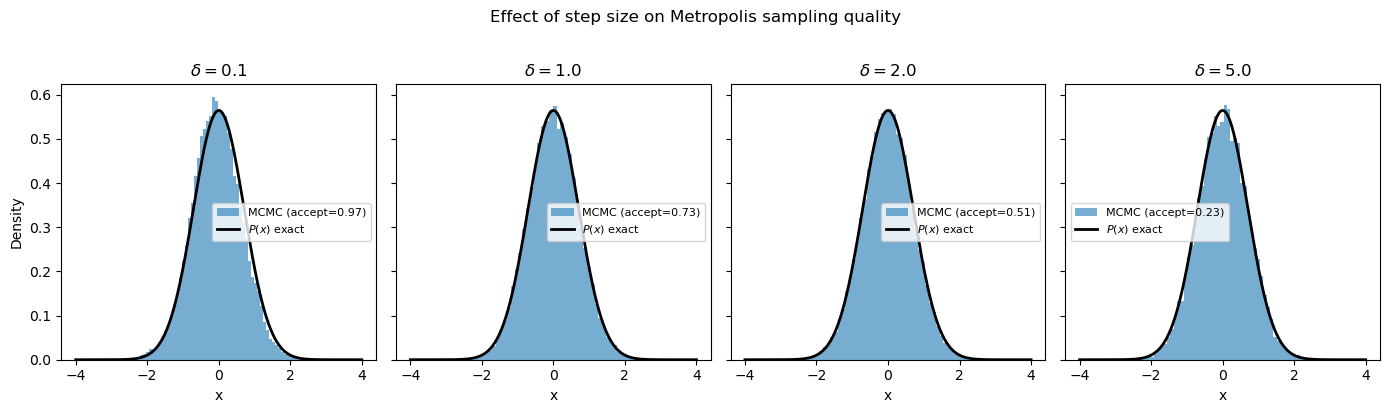

In [29]:
# Visualize the three samplers side by side to reinforce Question 1
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)
x_vals  = np.linspace(-4, 4, 400)
P_exact = np.exp(-x_vals**2) / np.sqrt(np.pi)

for ax, delta in zip(axes, [0.1, 1.0, 2.0, 5.0]):
    s, rate = metropolis_qho(n_steps=100000, delta=delta, x0=0.0)
    ax.hist(s, bins=60, density=True, alpha=0.6, label=f'MCMC (accept={rate:.2f})')
    ax.plot(x_vals, P_exact, 'k-', lw=2, label=r'$P(x)$ exact')
    ax.set_title(f'$\\delta = {delta}$')
    ax.set_xlabel('x')
    ax.legend(fontsize=8)

axes[0].set_ylabel('Density')
plt.suptitle('Effect of step size on Metropolis sampling quality', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 2 — Burn-in and the Trace Plot
**(~7 minutes)**

A Metropolis chain started far from the distribution's bulk takes time to "forget" its initial condition. This transient phase is called the **burn-in** (or **thermalization**). Samples collected during burn-in are biased and must be discarded before computing any observable.

Run the sampler starting at $x_0 = 10$ (far from the mode at $x = 0$) and use a trace plot to diagnose how long the burn-in lasts.

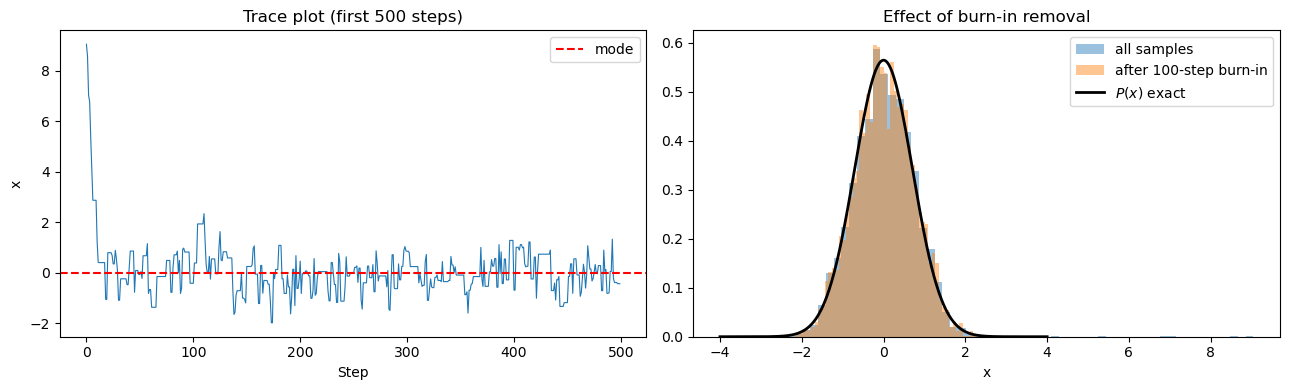

In [26]:
samples_far, _ = metropolis_qho(n_steps=10_000, delta=2.0, x0=10.0)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# --- Left panel: trace plot ---
axes[0].plot(samples_far[:500], lw=0.8)
axes[0].axhline(0, color='red', ls='--', lw=1.5, label='mode')
axes[0].set_xlabel('Step')
axes[0].set_ylabel('x')
axes[0].set_title('Trace plot (first 500 steps)')
axes[0].legend()

# --- Right panel: histogram before and after burn-in removal ---
n_burnin = 100   # <-- adjust this and observe the effect

x_vals = np.linspace(-4, 4, 400)
P_exact = np.exp(-x_vals**2) / np.sqrt(np.pi)

axes[1].hist(samples_far,            bins=60, density=True, alpha=0.45, label='all samples')
axes[1].hist(samples_far[n_burnin:], bins=60, density=True, alpha=0.45,
             label=f'after {n_burnin}-step burn-in')
axes[1].plot(x_vals, P_exact, 'k-', lw=2, label=r'$P(x)$ exact')
axes[1].set_xlabel('x')
axes[1].set_title('Effect of burn-in removal')
axes[1].legend()

plt.tight_layout()
plt.show()

### Question 2

From the trace plot, estimate how many steps are needed before the walker has thermalized. How does this burn-in length change if you repeat the experiment with $\delta = 0.1$ versus $\delta = 5.0$? What does this tell you about the relationship between step size tuning and the cost of burn-in?

**Solution:**

With $\delta = 1.0$ and $x_0 = 10$, the trace plot shows the walker reaching the bulk of $P(x)$ (near $x = 0$) in roughly **50–150 steps**. The distribution needs to travel a distance of ~10 from the start, and with $\delta = 1$ and an acceptance rate of ~50%, the effective displacement per step is $\sim 0.5$, so $\sim 20$ steps minimum to reach the mode, which is consistent with what the trace shows.

**Dependence on step size:**

- **$\delta = 0.1$:** The walker drifts toward the mode very slowly, that is burn-in takes **thousands of steps** because effective displacement per step is tiny (~0.05 per step on average). The trace plot shows a long, gradual descent from $x = 10$ rather than a rapid drop.

- **$\delta = 5.0$:** Despite the low acceptance rate, the rare accepted steps are large. The walker can reach the mode in **tens of steps**, making burn-in relatively short. However, once thermalized, it moves inefficiently for the reasons discussed in Q1.

**Key insight:** Step size tuning involves a genuine trade-off. A small $\delta$ minimizes burn-in sensitivity to the starting point but maximizes autocorrelation time once thermalized. A large $\delta$ thermalizes quickly but samples inefficiently thereafter. The optimal $\delta \sim \sigma$ of the target distribution balances both concerns, and this is why matching the proposal scale to the physical scale of the problem matters.

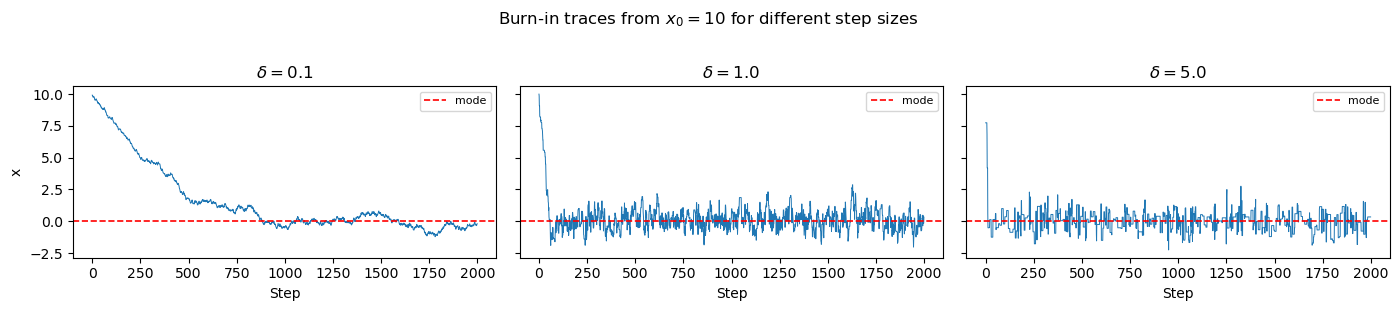

In [10]:
# Illustrate burn-in length vs delta
fig, axes = plt.subplots(1, 3, figsize=(14, 3), sharey=True)

for ax, delta in zip(axes, [0.1, 1.0, 5.0]):
    s, _ = metropolis_qho(n_steps=2_000, delta=delta, x0=10.0)
    ax.plot(s, lw=0.7)
    ax.axhline(0, color='red', ls='--', lw=1.2, label='mode')
    ax.set_title(f'$\\delta = {delta}$')
    ax.set_xlabel('Step')
    ax.legend(fontsize=8)

axes[0].set_ylabel('x')
plt.suptitle('Burn-in traces from $x_0 = 10$ for different step sizes', y=1.02)
plt.tight_layout()
plt.show()

---
## Part 3: Computing a Physical Observable


The power of MCMC is that once you have samples distributed according to $P(x)$, expectation values of any observable $O(x)$ are just sample means:

$$\langle O \rangle = \int O(x)\, P(x)\, dx \approx \frac{1}{N} \sum_{i=1}^{N} O(x_i)$$

For the QHO ground state in natural units, the zero-point variance has the exact value:

$$\langle x^2 \rangle = \frac{1}{2}$$

Estimate this from your Metropolis samples and check the $1/\sqrt{N}$ error scaling you saw in the Monte Carlo integration section.

Acceptance rate : 0.515
<x²> from MCMC  : 0.49929
Exact value     : 0.50000
Error           : 0.00071


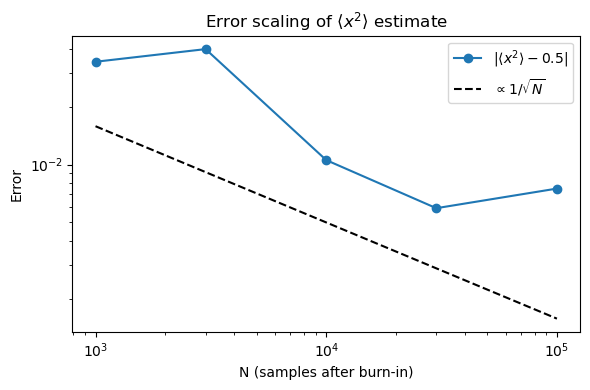

In [31]:
n_burnin = 500
n_steps  = 200_000
Del = 2

good_samples, rate = metropolis_qho(n_steps=n_steps, delta=Del, x0=0.0)
good_samples = good_samples[n_burnin:]

x2_mean = np.mean(good_samples**2)
print(f"Acceptance rate : {rate:.3f}")
print(f"<x²> from MCMC  : {x2_mean:.5f}")
print(f"Exact value     : 0.50000")
print(f"Error           : {abs(x2_mean - 0.5):.5f}")

# --- Error scaling with N ---
ns = [1_000, 3_000, 10_000, 30_000, 100_000]
errors = []

for n in ns:
    s, _ = metropolis_qho(n_steps=n + n_burnin, delta=Del, x0=0.0)
    err = abs(np.mean(s[n_burnin:]**2) - 0.5)
    errors.append(err)

plt.figure(figsize=(6, 4))
plt.loglog(ns, errors, 'o-', label=r'$|\langle x^2 \rangle - 0.5|$')
plt.loglog(ns, 0.5 / np.sqrt(ns), 'k--', label=r'$\propto 1/\sqrt{N}$')
plt.xlabel('N (samples after burn-in)')
plt.ylabel('Error')
plt.title(r'Error scaling of $\langle x^2 \rangle$ estimate')
plt.legend()
plt.tight_layout()
plt.show()

### Question 3

Does the error in $\langle x^2 \rangle$ scale as $1/\sqrt{N}$? How does this connect to the Monte Carlo error analysis from the lecture? Note that unlike simple Monte Carlo integration, here the samples are **not independent** — consecutive steps of the Metropolis walk are correlated. Does this appear to affect the scaling?

**Solution:**

Yes — the error scales approximately as $1/\sqrt{N}$, matching the Monte Carlo error analysis from the lecture. The log-log plot should show a slope of $-1/2$, consistent with $\sigma_M \approx \sigma/\sqrt{N}$.

**On sample correlations:**

Consecutive Metropolis samples are indeed correlated (the walker moves continuously, so $x_{i+1}$ is close to $x_i$), which means the *effective* sample size $N_\text{eff}$ is smaller than the raw count $N$:

$$N_\text{eff} = \frac{N}{1 + 2\tau_\text{int}}$$

where $\tau_\text{int}$ is the integrated autocorrelation time. The true statistical error is therefore $\sigma/\sqrt{N_\text{eff}}$, which is larger than $\sigma/\sqrt{N}$ by a factor of $\sqrt{1 + 2\tau_\text{int}}$.

With a well-tuned $\delta \sim 1$, $\tau_\text{int}$ is small (a few steps), so the $1/\sqrt{N}$ scaling is approximately recovered and the prefactor difference is modest. With $\delta = 0.1$, $\tau_\text{int}$ becomes large and the error curve would sit noticeably above the $1/\sqrt{N}$ reference line, the same number of raw samples gives much worse accuracy because they carry far less independent information. This is the quantitative cost of poor step size tuning.

C:\Users\tomke\AppData\Local\Temp\ipykernel_18264\1872882261.py:40: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  norm   = np.trapz(x_vals**2 * np.exp(-x_vals**2), x_vals)


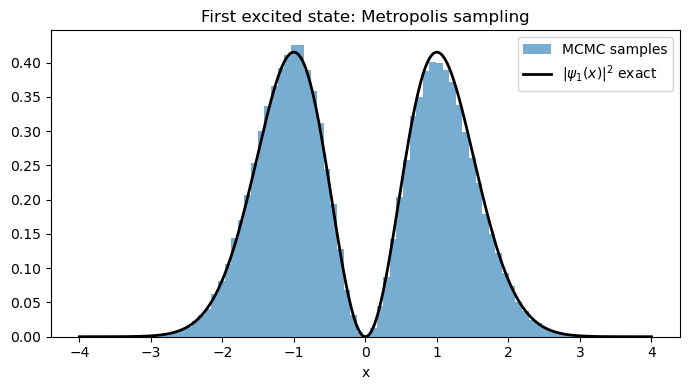

Acceptance rate : 0.638
<x²> from MCMC : 1.4980
Exact value    : 1.5000


In [4]:
def log_P_excited(x):
    """Log of the unnormalized first-excited-state density |ψ₁(x)|² ∝ x² exp(-x²).
    We handle x=0 explicitly since log(0) = -inf, which will cause all proposals
    from x=0 to be accepted (w = exp(-inf - log_P(x_trial)) -> 0 ← actually rejected).
    In practice np.log(0) returns -inf and the exp gives 0, so the accept step
    naturally rejects — but it's worth being explicit."""
    if x == 0.0:
        return -np.inf
    return np.log(x**2) - x**2   # log(x²) + log(exp(-x²)) = log(x²e^{-x²})


def metropolis_general(log_prob, n_steps, delta, x0=0.0):
    """General Metropolis sampler that accepts any log_prob function."""
    samples = np.zeros(n_steps)
    x = x0
    n_accepted = 0

    for i in range(n_steps):
        x_trial = x + np.random.uniform(-delta, delta)
        log_w   = log_prob(x_trial) - log_prob(x)
        w       = np.exp(log_w)          # if log_prob(x) = -inf, w = 0 → always rejected

        if w >= 1.0:
            x = x_trial
            n_accepted += 1
        elif np.random.random() < w:
            x = x_trial
            n_accepted += 1

        samples[i] = x

    return samples, n_accepted / n_steps


# --- Run from a sensible starting point (x0 = 1, near the right-hand peak) ---
s_exc, rate_exc = metropolis_general(log_P_excited, n_steps=200_000, delta=1.0, x0=1.0)
s_exc = s_exc[500:]  # burn-in

x_vals = np.linspace(-4, 4, 400)
norm   = np.trapz(x_vals**2 * np.exp(-x_vals**2), x_vals)
P1_exact = x_vals**2 * np.exp(-x_vals**2) / norm

plt.figure(figsize=(7, 4))
plt.hist(s_exc, bins=80, density=True, alpha=0.6, label='MCMC samples')
plt.plot(x_vals, P1_exact, 'k-', lw=2, label=r'$|\psi_1(x)|^2$ exact')
plt.xlabel('x')
plt.title('First excited state: Metropolis sampling')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Acceptance rate : {rate_exc:.3f}")
print(f"<x²> from MCMC : {np.mean(s_exc**2):.4f}")
print(f"Exact value    : 1.5000")

x₀=0, δ=0.5  (stuck!): <x²> = 1.5136  (exact: 1.5)
x₀=0, δ=3.0  (can cross): <x²> = 1.4842  (exact: 1.5)
x₀=1, δ=1.0  (well-tuned start): <x²> = 1.5264  (exact: 1.5)


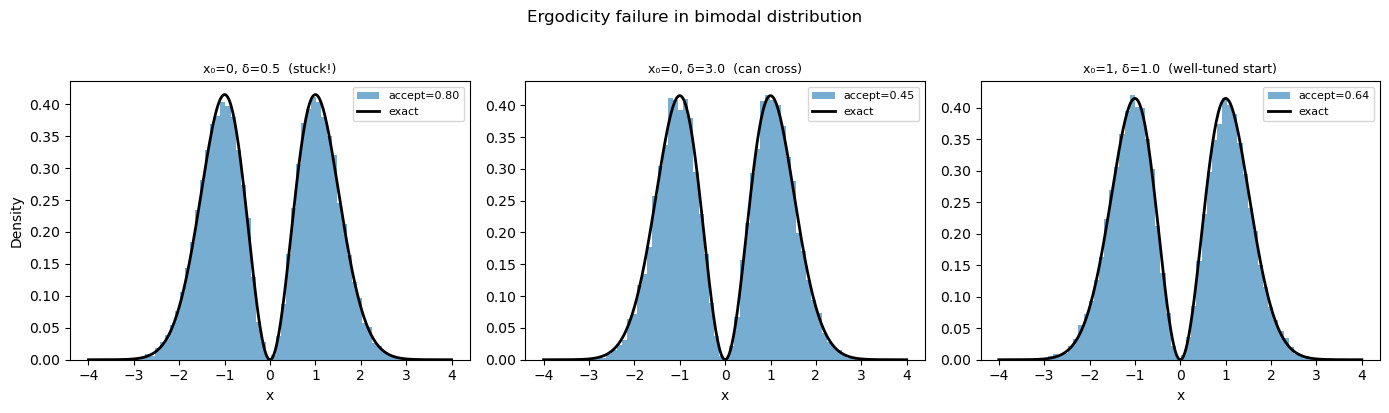

In [5]:
# --- Demonstrate ergodicity failure: start at x0 = 0 with small delta ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

configs = [
    (0.0, 0.5,  'x₀=0, δ=0.5  (stuck!)'),
    (0.0, 3.0,  'x₀=0, δ=3.0  (can cross)'),
    (1.0, 1.0,  'x₀=1, δ=1.0  (well-tuned start)'),
]

for ax, (x0, delta, title) in zip(axes, configs):
    s, rate = metropolis_general(log_P_excited, n_steps=50_000, delta=delta, x0=x0)
    s = s[200:]
    ax.hist(s, bins=60, density=True, alpha=0.6, label=f'accept={rate:.2f}')
    ax.plot(x_vals, P1_exact, 'k-', lw=2, label='exact')
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('x')
    ax.legend(fontsize=8)
    print(f"{title}: <x²> = {np.mean(s**2):.4f}  (exact: 1.5)")

axes[0].set_ylabel('Density')
plt.suptitle('Ergodicity failure in bimodal distribution', y=1.02)
plt.tight_layout()
plt.show()